In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import cv2
from collections import Counter

In [14]:
metadata = pd.read_csv(r'C:\Users\ASUS\MMDP\DiverseVisuals\metadata.csv')

In [15]:
print("Dataset Overview:")
print(metadata.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Category    974 non-null    object
 1   Filename    974 non-null    object
 2   URL         974 non-null    object
 3   Resolution  974 non-null    object
dtypes: object(4)
memory usage: 30.6+ KB
None


In [16]:
# Check for missing values:
print("\nMissing Values:")
print(metadata.isnull().sum())


Missing Values:
Category      0
Filename      0
URL           0
Resolution    0
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17112\1373671053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=metadata["Category"], order=metadata["Category"].value_counts().index, palette="viridis")


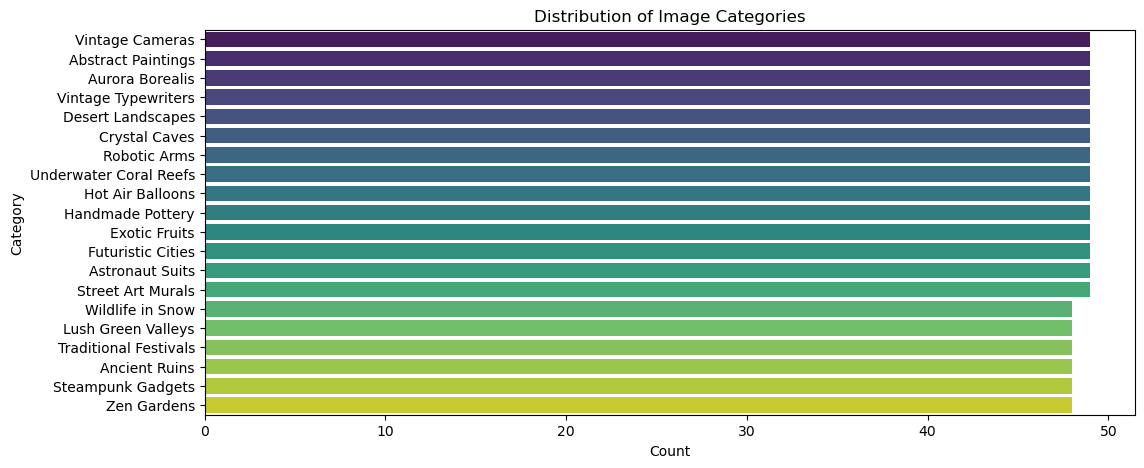

In [17]:
# Check category distribution
plt.figure(figsize=(12, 5))
sns.countplot(y=metadata["Category"], order=metadata["Category"].value_counts().index, palette="viridis")
plt.xlabel("Count")
plt.ylabel("Category")
plt.title("Distribution of Image Categories")
plt.show()

In [19]:
metadata.head()

,Category,Filename,URL,Resolution
0,Vintage Cameras,Vintage_Cameras_1.jpg,https://encrypted-tbn0.gstatic.com/images?q=tb...,274x184
1,Vintage Cameras,Vintage_Cameras_2.jpg,https://encrypted-tbn0.gstatic.com/images?q=tb...,183x275
2,Vintage Cameras,Vintage_Cameras_3.jpg,https://encrypted-tbn0.gstatic.com/images?q=tb...,180x180
3,Vintage Cameras,Vintage_Cameras_4.jpg,https://encrypted-tbn0.gstatic.com/images?q=tb...,275x183
4,Vintage Cameras,Vintage_Cameras_5.jpg,https://encrypted-tbn0.gstatic.com/images?q=tb...,263x192


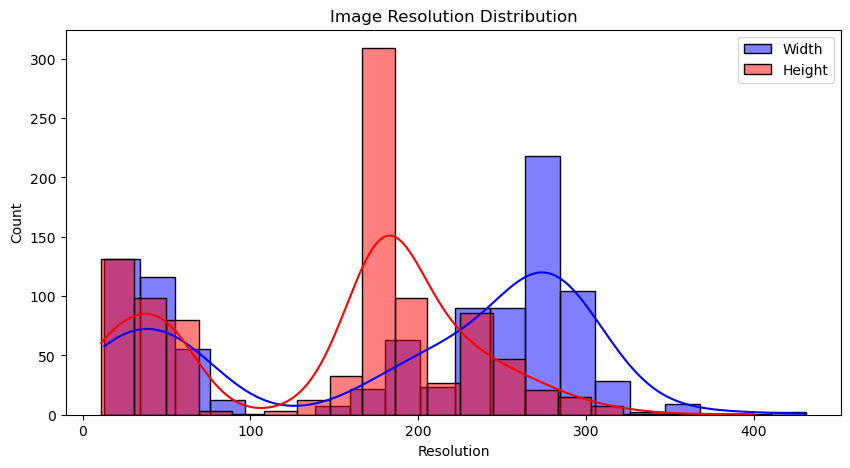

In [20]:
metadata["Width"] = metadata["Resolution"].apply(lambda x: int(x.split('x')[0]))
metadata["Height"] = metadata["Resolution"].apply(lambda x: int(x.split('x')[1]))

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(metadata["Width"], bins=20, color="blue", label="Width", kde=True)
sns.histplot(metadata["Height"], bins=20, color="red", label="Height", kde=True)
plt.xlabel("Resolution")
plt.ylabel("Count")
plt.legend()
plt.title("Image Resolution Distribution")
plt.show()

In [37]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.manifold import TSNE
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import keras_tuner as kt

In [38]:
resnet = ResNet50(weights="imagenet", include_top=False, pooling="avg")
densenet = DenseNet121(weights="imagenet", include_top=False, pooling="avg")
def extract_features(image_path):
    try:
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)
        features = densenet.predict(img_array)
        return features.flatten()
    except Exception as e:
        print(f"Error: {e}")
        return None

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [39]:
features = []
valid_indices = []

for i, row in metadata.iterrows():
    image_path = os.path.join(r'C:\Users\ASUS\MMDP\DiverseVisuals', row["Category"].replace(" ", "_"), row["Filename"])
    feature = extract_features(image_path)
    if feature is not None:
        features.append(feature)
        valid_indices.append(i)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━

## TSNE with DenseNet121:

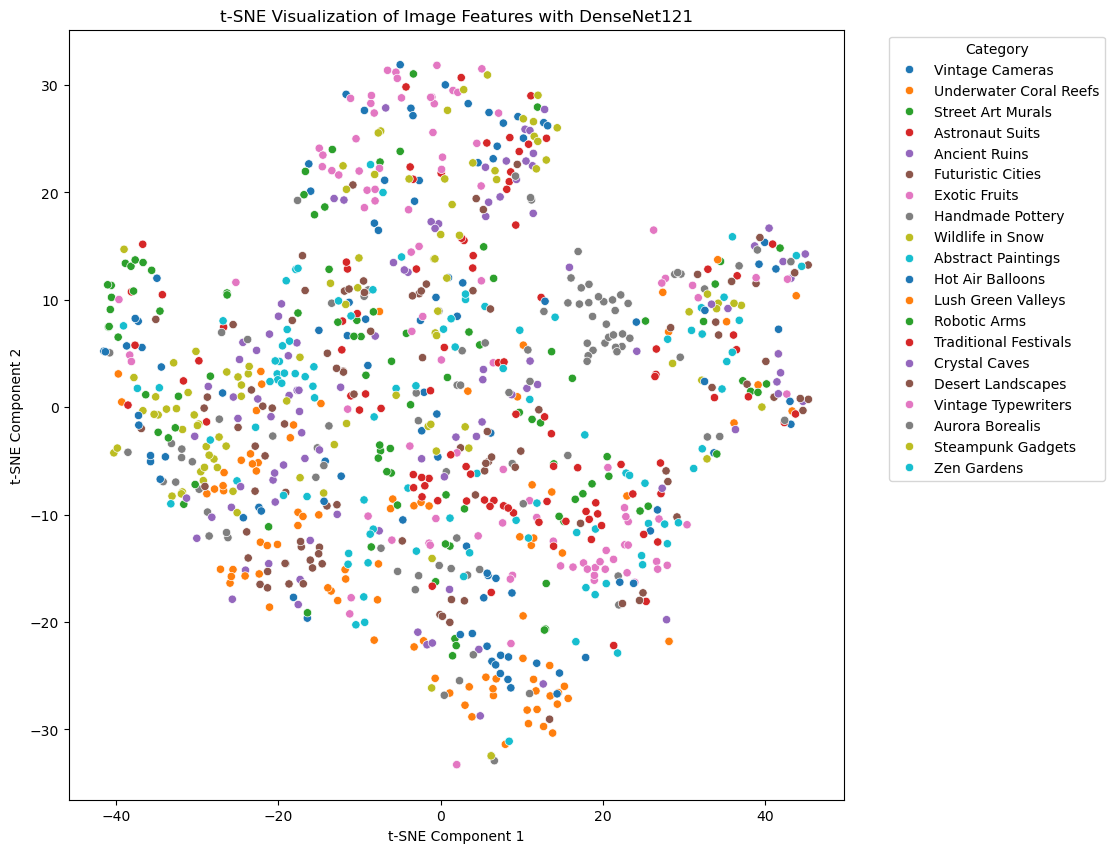

In [41]:
features = np.array(features)

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(features)

# Plot t-SNE
plt.figure(figsize=(10, 10))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=metadata.loc[valid_indices, "Category"], palette="tab10", legend="full")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Image Features with DenseNet121")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='best')
plt.show()

In [42]:
def extract_features_resnet(image_path):
    try:
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)
        features = resnet.predict(img_array)
        return features.flatten()
    except Exception as e:
        print(f"Error: {e}")
        return None

In [43]:
features_res = []
valid_indices_res = []

for i, row in metadata.iterrows():
    image_path = os.path.join(r'C:\Users\ASUS\MMDP\DiverseVisuals', row["Category"].replace(" ", "_"), row["Filename"])
    feature = extract_features_resnet(image_path)
    if feature is not None:
        features_res.append(feature)
        valid_indices_res.append(i)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━

## TSNE with RESNET50:

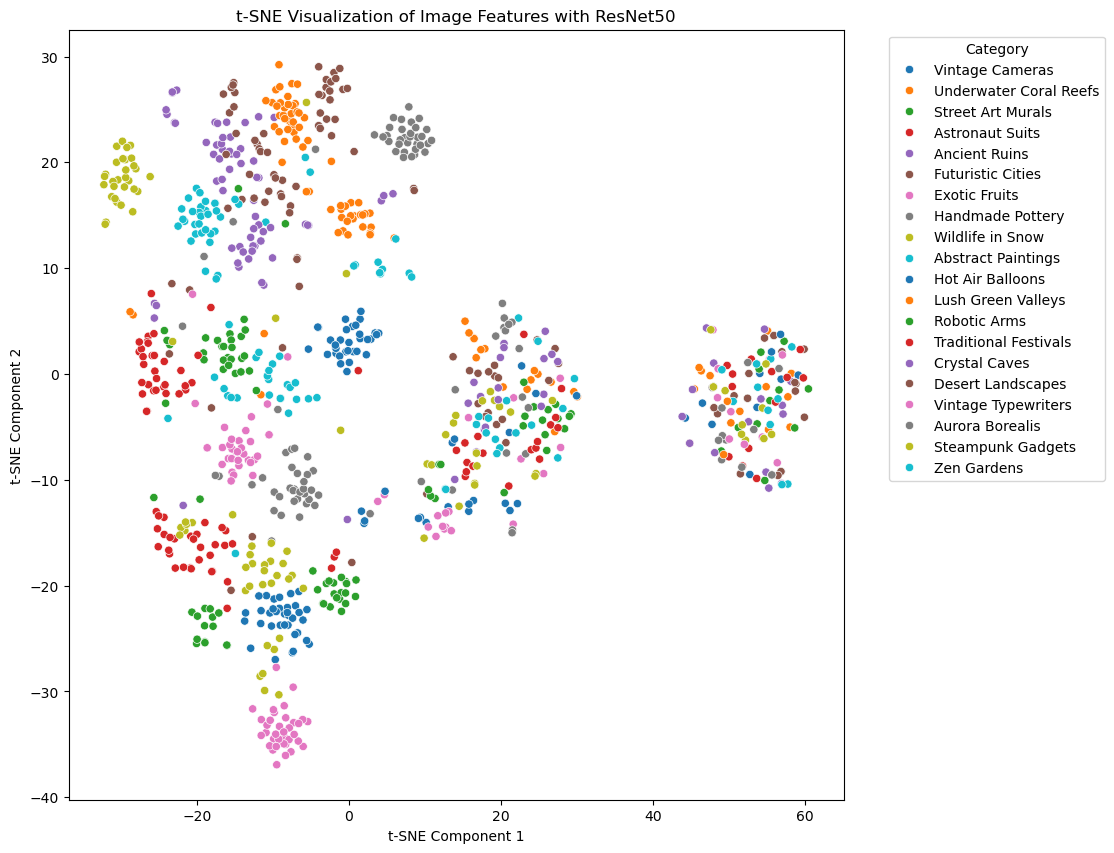

In [45]:
features_res = np.array(features_res)

# Perform t-SNE
tsne_res = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results_res = tsne.fit_transform(features_res)

# Plot t-SNE
plt.figure(figsize=(10, 10))
sns.scatterplot(x=tsne_results_res[:, 0], y=tsne_results_res[:, 1], hue=metadata.loc[valid_indices_res, "Category"], palette="tab10", legend="full")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Image Features with ResNet50")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='best')
plt.show()

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [52]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    height_shift_range=0.2,
    width_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2
)

In [53]:
data_dir = r'C:\Users\ASUS\MMDP\DiverseVisuals'
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 794 images belonging to 20 classes.
Found 180 images belonging to 20 classes.


In [54]:
# Freeze ResNet50 layers
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in resnet.layers:
    layer.trainable = False

model = Sequential([
    resnet,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

In [55]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,773,268 (94.50 MB)

 Trainable params: 1,185,556 (4.52 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Training Normally:

In [56]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.0378 - loss: 3.0957 - val_accuracy: 0.0500 - val_loss: 2.9867
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.0623 - loss: 2.9945 - val_accuracy: 0.1056 - val_loss: 2.9711
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.0580 - loss: 2.9742 - val_accuracy: 0.1056 - val_loss: 2.9493
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.0890 - loss: 2.9444 - val_accuracy: 0.0722 - val_loss: 2.9309
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.0801 - loss: 2.9432 - val_accuracy: 0.0833 - val_loss: 2.9206
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.0901 - loss: 2.9277 - val_accuracy: 0.1389 - val_loss: 2.8950
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1069 - loss: 2.9157 - val_accuracy: 0.1222 - val_loss: 2.9128
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1080 - loss: 2.8978 - val_accuracy: 0.1278 - val_loss:

In [57]:
model.save("resnet_image_classifier.h5")

Text(0.5, 1.0, 'Model Loss')

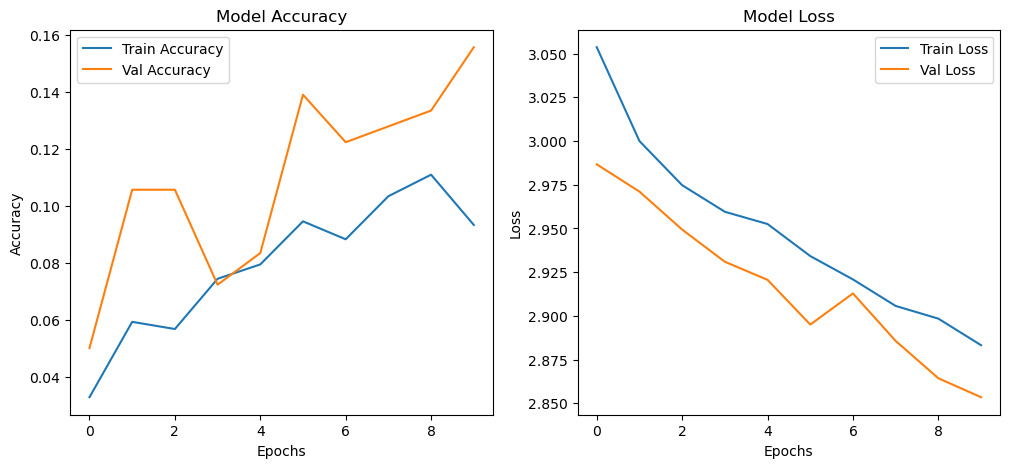

In [58]:
# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")

## Training with Optimization:

In [61]:
reduce_lr = ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.1080 - loss: 2.8801 - val_accuracy: 0.1556 - val_loss: 2.8549 - learning_rate: 1.0000e-04
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.1392 - loss: 2.8473 - val_accuracy: 0.1500 - val_loss: 2.8463 - learning_rate: 1.0000e-04
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.1298 - loss: 2.8517 - val_accuracy: 0.1667 - val_loss: 2.8345 - learning_rate: 1.0000e-04
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.1218 - loss: 2.8495 - val_accuracy: 0.1278 - val_loss: 2.8438 - learning_rate: 1.0000e-04
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.1166 - loss: 2.8462 - val_accuracy: 0.1833 - val_loss: 2.8247 - learning_rate: 1.0000e-04
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.1350 - loss: 2.8262 - val_accuracy: 0.1333 - val_loss: 2.8232 - learning_rate: 1.0000e-04
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1249 - loss:

In [62]:
model.save("resnet_image_classifier_tuned.h5")

In [63]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1508 - loss: 2.8586
Validation Accuracy: 0.1667


Text(0.5, 1.0, 'Model Loss')

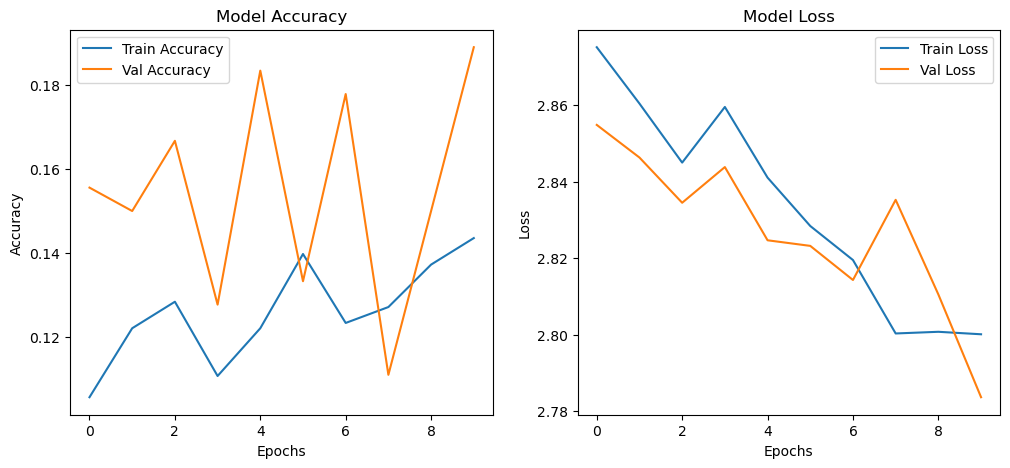

In [64]:
# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")

In [65]:
for layer in densenet.layers:
    layer.trainable = False

model_densenet = Sequential([
    densenet,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

In [66]:
model_densenet.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model_densenet.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,698,772 (29.37 MB)

 Trainable params: 661,268 (2.52 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [67]:
# Train the model
history_dense = model_densenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.0790 - loss: 3.0783 - val_accuracy: 0.1889 - val_loss: 2.7282 - learning_rate: 1.0000e-04
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.3059 - loss: 2.6013 - val_accuracy: 0.4278 - val_loss: 2.3814 - learning_rate: 1.0000e-04
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.4345 - loss: 2.2649 - val_accuracy: 0.4778 - val_loss: 2.0724 - learning_rate: 1.0000e-04
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.5718 - loss: 1.8854 - val_accuracy: 0.5444 - val_loss: 1.8055 - learning_rate: 1.0000e-04
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.6586 - loss: 1.5817 - val_accuracy: 0.5778 - val_loss: 1.6001 - learning_rate: 1.0000e-04
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6759 - loss: 1.3564 - val_accuracy: 0.5667 - val_loss: 1.5326 - learning_rate: 1.0000e-04
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6425 - loss:

Text(0.5, 1.0, 'Model Loss')

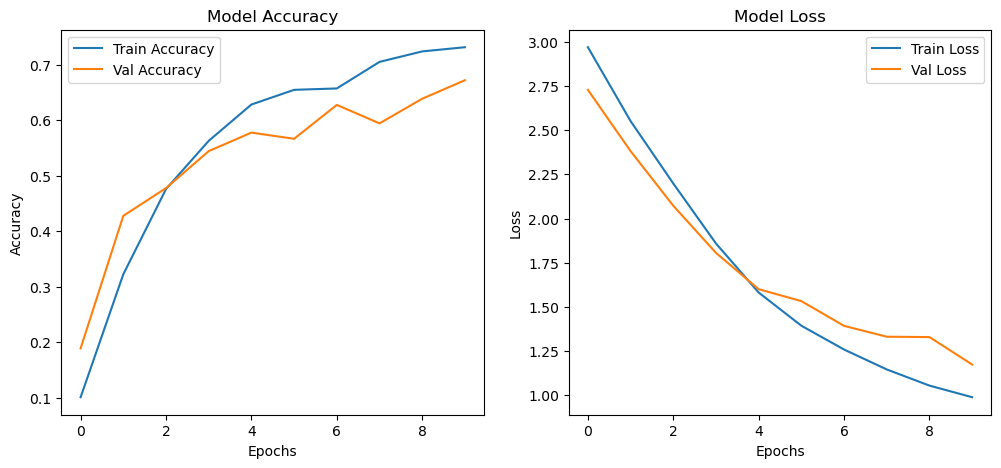

In [68]:
# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_dense.history["accuracy"], label="Train Accuracy")
plt.plot(history_dense.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_dense.history["loss"], label="Train Loss")
plt.plot(history_dense.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")

In [69]:
loss, accuracy = model_densenet.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6055 - loss: 1.3298
Validation Accuracy: 0.6333


In [70]:
model_densenet.save("densenet_image_classifier_tuned.h5")

In [71]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

In [72]:
#model = load_model("resnet_image_classifier_tuned.h5")
model_densenet = load_model("densenet_image_classifier_tuned.h5")

In [77]:
class_labels = list(train_generator.class_indices.keys())

def preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

In [75]:
image_dir = r'C:\Users\ASUS\MMDP\DiverseVisuals'
categories = os.listdir(image_dir)
sample_images = []

for category in categories:
    if category == 'metadata.csv':
        continue
    image_path = os.path.join(image_dir, category, os.listdir(os.path.join(image_dir, category))[0])
    sample_images.append(image_path)
